# Content-Based Movie Recommendation System
**Data Mining Course Project**  
Dataset: `wiki_movie_plots_deduped.csv` (~34k movies)

In [ ]:
Ali Kaan Demiralp
Tunay Can
Mona Hamdane

## Dataset Summary

| Field | Value |
|---|---|
| **Source** | Wikipedia Movie Plots Dataset (Kaggle, deduped version, accessed via local CSV) |
| **Records (original)** | 34,886 movies |
| **Records (after preprocessing)** | 24,959 movies |
| **Users** | None — this dataset contains no user-item interactions or ratings |
| **Items** | 24,959 unique movies after preprocessing |

**Columns and what each represents:**

| Column | Description |
|---|---|
| `Release_Year` | Year the movie was released |
| `Title` | Movie title |
| `Origin_Ethnicity` | Country/cultural origin of the film |
| `Director` | Director name(s) |
| `Cast` | Lead cast members |
| `Genre` | One or more genre labels (comma-separated) |
| `Wiki_Page` | URL of the Wikipedia article |
| `Plot` | Free-text plot summary sourced from Wikipedia |

**Features used for recommendation:** `Plot` (textual) and `Genre` (categorical).

Because this dataset contains no user-item ratings or interactions, this project implements an item-to-item content-based recommendation system, as explicitly permitted by Section 8 of the Instructor Project Guide.

---
## Phase 1: Data Exploration & Preprocessing

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
from collections import Counter

warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

### 1.1 Load Data

In [32]:
df = pd.read_csv('wiki_movie_plots_deduped.csv')

# Standardise column names: strip whitespace, replace spaces with underscores
df.columns = df.columns.str.strip().str.replace(' ', '_').str.replace('/', '_')
print('Columns:', df.columns.tolist())

Columns: ['Release_Year', 'Title', 'Origin_Ethnicity', 'Director', 'Cast', 'Genre', 'Wiki_Page', 'Plot']


### 1.2 Shape, dtypes, head, and info

In [33]:
print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} columns\n')
print('dtypes:')
print(df.dtypes)
print()
df.head()

Shape: 34,886 rows × 8 columns

dtypes:
Release_Year        int64
Title                 str
Origin_Ethnicity      str
Director              str
Cast                  str
Genre                 str
Wiki_Page             str
Plot                  str
dtype: object



,Release_Year,Title,Origin_Ethnicity,Director,Cast,Genre,Wiki_Page,Plot
0,1901,Kansas Saloon Smashers,American,Unknown,NaN,unknown,https://en.wikipedia.org/wiki/Kansas_Saloon_Sm...,"A bartender is working at a saloon, serving dr..."
1,1901,Love by the Light of the Moon,American,Unknown,NaN,unknown,https://en.wikipedia.org/wiki/Love_by_the_Ligh...,"The moon, painted with a smiling face hangs ov..."
2,1901,The Martyred Presidents,American,Unknown,NaN,unknown,https://en.wikipedia.org/wiki/The_Martyred_Pre...,"The film, just over a minute long, is composed..."
3,1901,"Terrible Teddy, the Grizzly King",American,Unknown,NaN,unknown,"https://en.wikipedia.org/wiki/Terrible_Teddy,_...",Lasting just 61 seconds and consisting of two ...
4,1902,Jack and the Beanstalk,American,"George S. Fleming, Edwin S. Porter",NaN,unknown,https://en.wikipedia.org/wiki/Jack_and_the_Bea...,The earliest known adaptation of the classic f...


In [34]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 34886 entries, 0 to 34885
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Release_Year      34886 non-null  int64
 1   Title             34886 non-null  str  
 2   Origin_Ethnicity  34886 non-null  str  
 3   Director          34886 non-null  str  
 4   Cast              33464 non-null  str  
 5   Genre             34886 non-null  str  
 6   Wiki_Page         34886 non-null  str  
 7   Plot              34886 non-null  str  
dtypes: int64(1), str(7)
memory usage: 2.1 MB


### 1.3 Missing Value Analysis
Treat `NaN`, empty strings, and case-insensitive `"unknown"` as missing for **Genre**, **Director**, and **Cast**.

In [35]:
# Standard NaN counts
nan_counts = df.isna().sum().rename('NaN')

# Extended missing: NaN + empty string + "unknown" for the three semantic columns
SEMANTIC_COLS = ['Genre', 'Director', 'Cast']

def is_missing_extended(series):
    """True where value is NaN, empty string, or 'unknown' (case-insensitive)."""
    return series.isna() | (series.astype(str).str.strip().str.lower().isin(['', 'unknown']))

extended_counts = {}
for col in df.columns:
    if col in SEMANTIC_COLS:
        extended_counts[col] = is_missing_extended(df[col]).sum()
    else:
        extended_counts[col] = df[col].isna().sum()

missing_df = pd.DataFrame({
    'NaN_only': nan_counts,
    'Extended_missing': pd.Series(extended_counts)
})
missing_df['Extended_%'] = (missing_df['Extended_missing'] / len(df) * 100).round(2)
print('(* Extended missing applies NaN + empty + "unknown" to Genre, Director, Cast)\n')
missing_df.sort_values('Extended_missing', ascending=False)

(* Extended missing applies NaN + empty + "unknown" to Genre, Director, Cast)



,NaN_only,Extended_missing,Extended_%
Genre,0,6111,17.52
Cast,1422,1455,4.17
Director,0,1132,3.24
Release_Year,0,0,0.00
Origin_Ethnicity,0,0,0.00
Title,0,0,0.00
Wiki_Page,0,0,0.00
Plot,0,0,0.00


### 1.4 Duplicate Check

In [36]:
# Full-row duplicates
full_dups = df.duplicated().sum()
print(f'Full-row duplicates: {full_dups:,}')

# Title-only duplicates (same title, possibly different year/origin)
title_dups = df.duplicated(subset=['Title']).sum()
print(f'Title-only duplicates: {title_dups:,}')

# Title + Release Year duplicates
title_year_dups = df.duplicated(subset=['Title', 'Release_Year']).sum()
print(f'Title + Release Year duplicates: {title_year_dups:,}')

# Preview a few duplicated titles
dup_titles = df[df.duplicated(subset=['Title'], keep=False)][['Title', 'Release_Year', 'Origin_Ethnicity']]
print(f'\nSample rows with duplicated titles (first 10):')
dup_titles.sort_values('Title').head(10)

Full-row duplicates: 0
Title-only duplicates: 2,454
Title + Release Year duplicates: 278

Sample rows with duplicated titles (first 10):


,Title,Release_Year,Origin_Ethnicity
17813,$9.99,2009,Australian
17796,$9.99,2008,Australian
34228,10,2014,Russian
9556,10,1979,American
17168,100 Streets,2017,American
21611,100 Streets,2016,British
24073,100% Love,2012,Bengali
32475,100% Love,2011,Telugu
34130,12,2007,Russian
32245,12,2006,Telugu


### 1.5 Plot Length Distribution (word count)

Using plot column: "Plot"

Plot word count statistics:
  min    :        2
  max    :    6,752
  mean   :    372.5
  median :    284.0
  std    :    315.8
  p25    :    122.0
  p75    :    581.0
  p90    :    770.0
  p95    :    905.0
  p99    :  1,296.5


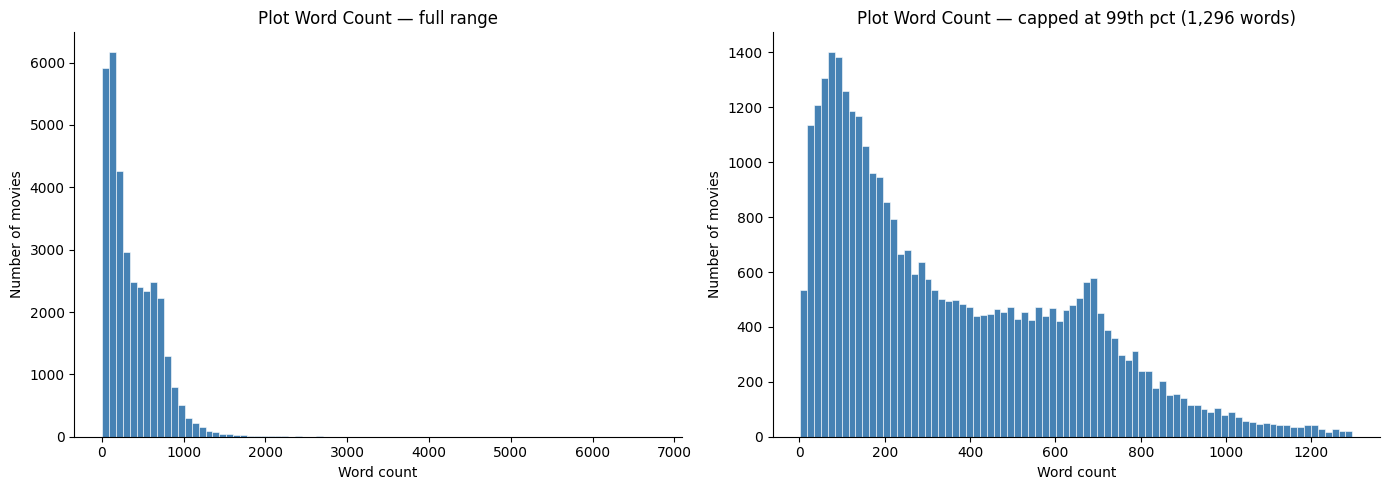

In [37]:
# Identify the plot column (handles minor naming variations)
plot_col = [c for c in df.columns if 'plot' in c.lower() or 'Plot' in c][0]
print(f'Using plot column: "{plot_col}"')

df['plot_word_count'] = df[plot_col].fillna('').str.split().str.len()

stats = df['plot_word_count'].describe(percentiles=[0.25, 0.5, 0.75, 0.90, 0.95, 0.99])
print('\nPlot word count statistics:')
print(f"  min    : {df['plot_word_count'].min():>8,}")
print(f"  max    : {df['plot_word_count'].max():>8,}")
print(f"  mean   : {df['plot_word_count'].mean():>8,.1f}")
print(f"  median : {df['plot_word_count'].median():>8,.1f}")
print(f"  std    : {df['plot_word_count'].std():>8,.1f}")
for p in [25, 75, 90, 95, 99]:
    print(f"  p{p:<2}    : {df['plot_word_count'].quantile(p/100):>8,.1f}")

# Histogram (capped at 99th percentile for readability)
cap = int(df['plot_word_count'].quantile(0.99))
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['plot_word_count'], bins=80, color='steelblue', edgecolor='white', linewidth=0.4)
axes[0].set_title('Plot Word Count — full range')
axes[0].set_xlabel('Word count')
axes[0].set_ylabel('Number of movies')

axes[1].hist(df.loc[df['plot_word_count'] <= cap, 'plot_word_count'],
             bins=80, color='steelblue', edgecolor='white', linewidth=0.4)
axes[1].set_title(f'Plot Word Count — capped at 99th pct ({cap:,} words)')
axes[1].set_xlabel('Word count')
axes[1].set_ylabel('Number of movies')

plt.tight_layout()
plt.show()

### 1.6 Genre Distribution

Using genre column: "Genre"

Top 30 raw genre values (whole cell):
Genre
unknown            6083
drama              5964
comedy             4379
horror             1167
action             1098
thriller            966
romance             923
western             865
crime               568
adventure           526
musical             467
crime drama         464
romantic comedy     461
science fiction     418
film noir           345
mystery             310
war                 273
animation           264
comedy, drama       236
sci-fi              221
family              217
fantasy             204
animated            195
musical comedy      154
comedy-drama        137
biography           136
anime               112
suspense            104
romantic drama      103
comedy drama        103


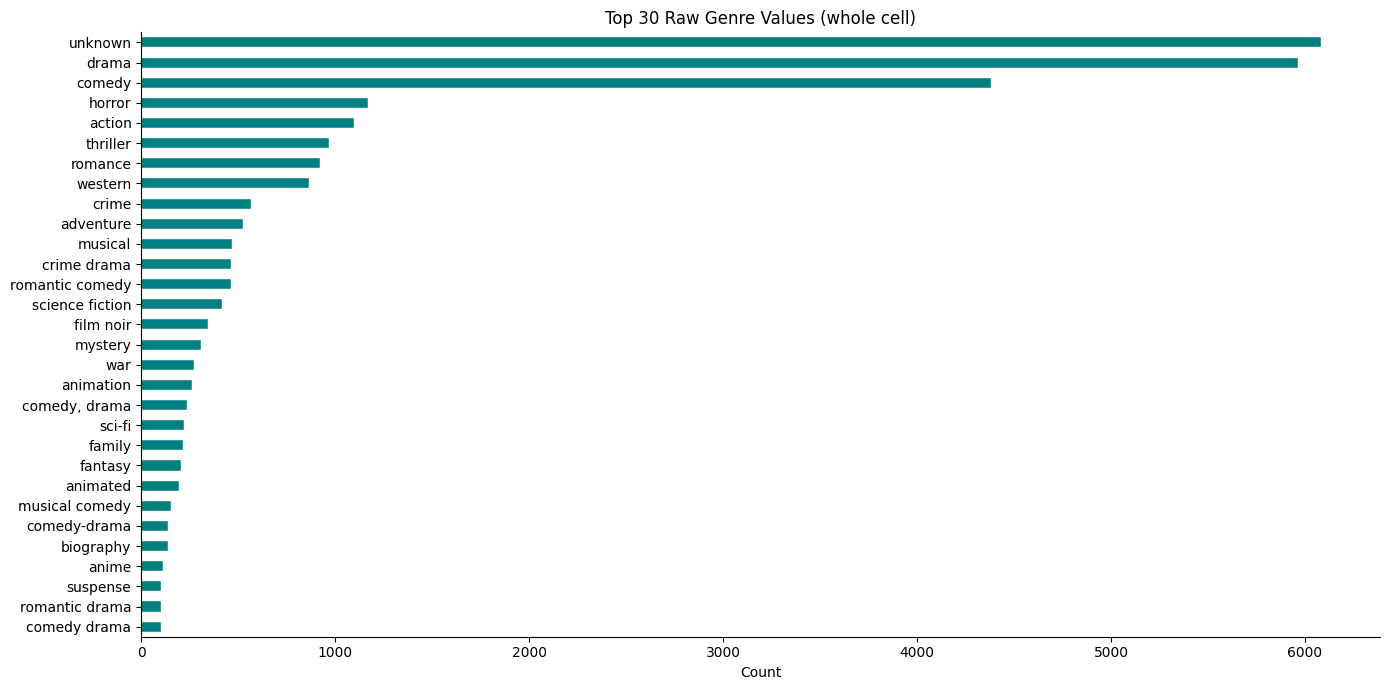

In [38]:
# Identify genre column
genre_col = [c for c in df.columns if 'genre' in c.lower()][0]
print(f'Using genre column: "{genre_col}"\n')

# --- Raw (whole-cell) top 30 ---
raw_genre_counts = df[genre_col].fillna('unknown').value_counts()
top30_raw = raw_genre_counts.head(30)

print('Top 30 raw genre values (whole cell):')
print(top30_raw.to_string())

fig, ax = plt.subplots(figsize=(14, 7))
top30_raw.sort_values().plot.barh(ax=ax, color='teal', edgecolor='white', linewidth=0.3)
ax.set_title('Top 30 Raw Genre Values (whole cell)')
ax.set_xlabel('Count')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

Unique individual genres (after normalisation): 1,447

Top 30 individual genres (normalised):
Genre
drama              7447
comedy             5381
action             1747
romance            1514
horror             1389
thriller           1286
western             929
crime               863
adventure           701
musical             701
science fiction     497
romantic comedy     490
family              487
crime drama         475
mystery             423
fantasy             398
war                 376
film noir           347
sci-fi              344
animation           302
biography           289
animated            251
comedy-drama        173
musical comedy      154
suspense            121
social              119
anime               115
romantic drama      108
historical          104
comedy drama        104


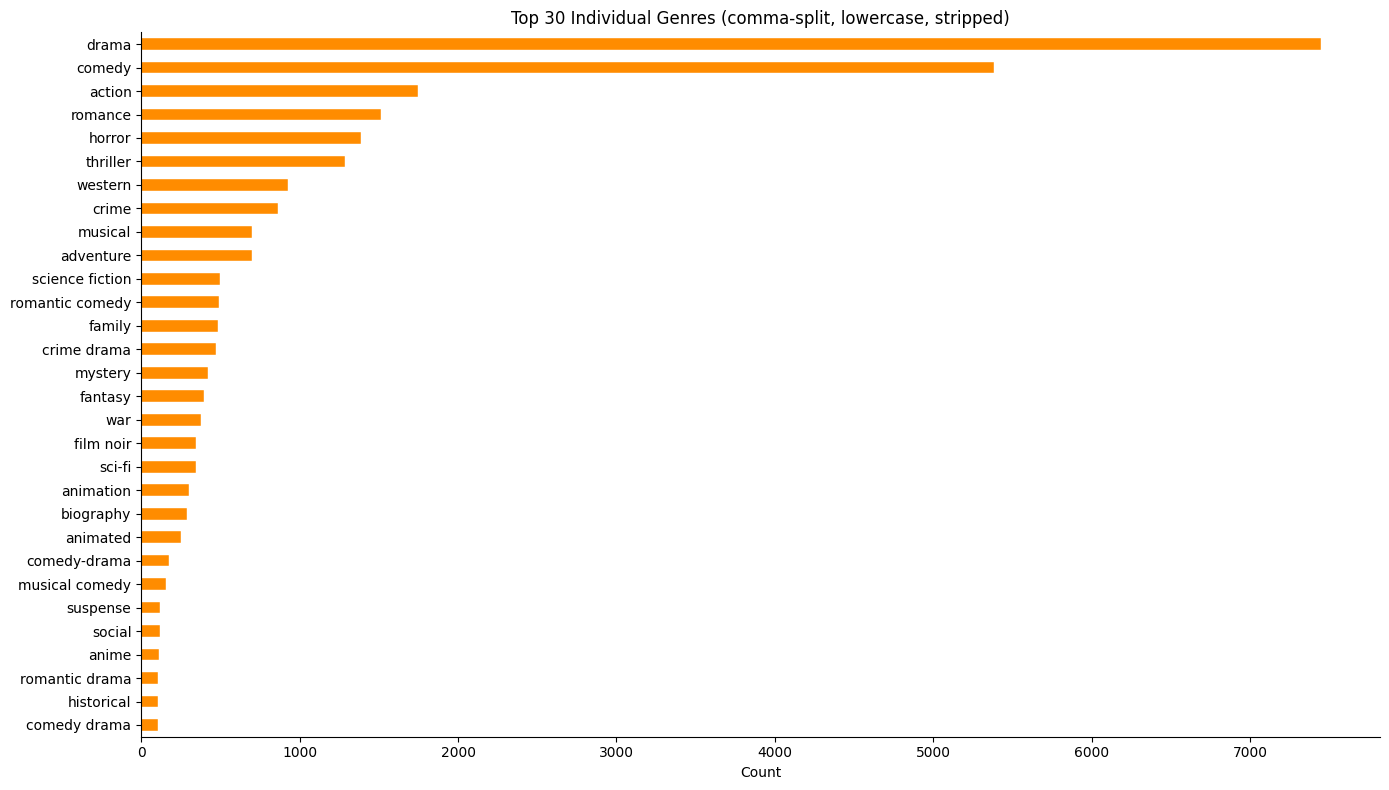

In [39]:
# --- Normalised: split on comma, lowercase, strip ---
genre_tokens = (
    df[genre_col]
    .dropna()
    .str.split(',')
    .explode()
    .str.strip()
    .str.lower()
    .replace('', np.nan)
    .dropna()
)

# Exclude "unknown"
genre_tokens = genre_tokens[genre_tokens != 'unknown']

norm_counts = genre_tokens.value_counts()
top30_norm = norm_counts.head(30)

print(f'Unique individual genres (after normalisation): {norm_counts.shape[0]:,}\n')
print('Top 30 individual genres (normalised):')
print(top30_norm.to_string())

fig, ax = plt.subplots(figsize=(14, 8))
top30_norm.sort_values().plot.barh(ax=ax, color='darkorange', edgecolor='white', linewidth=0.3)
ax.set_title('Top 30 Individual Genres (comma-split, lowercase, stripped)')
ax.set_xlabel('Count')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

### 1.7 Release Year Distribution

Using year column: "Release_Year"

Year range : 1901 – 2017
Missing/non-numeric years: 0


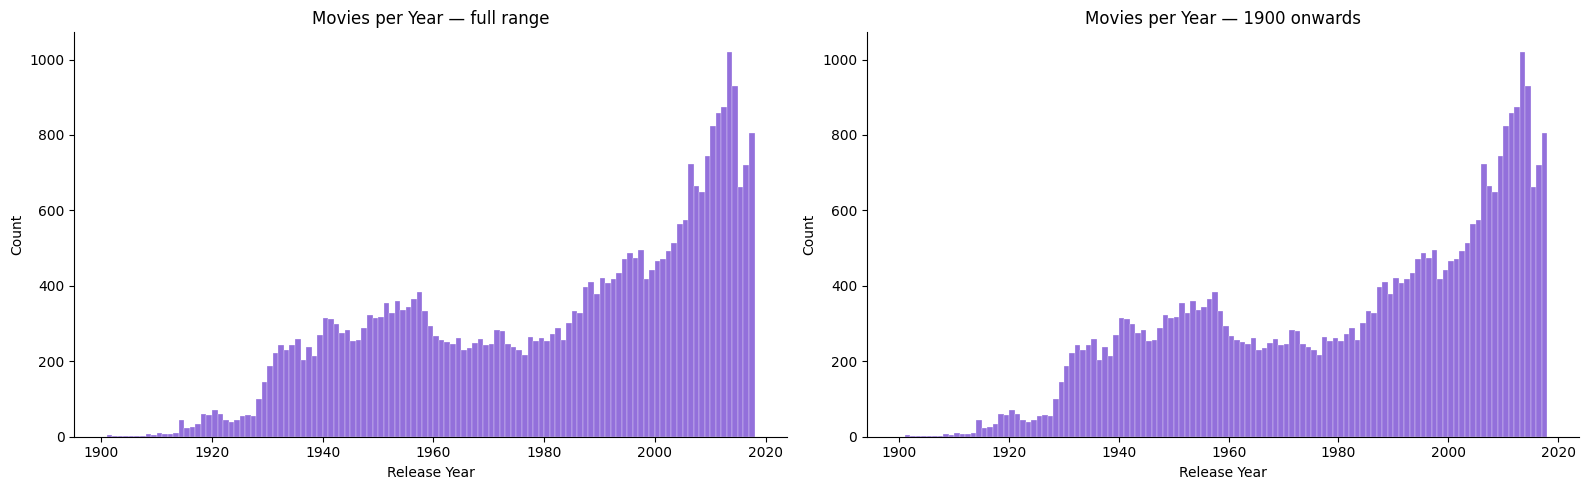


Movies per decade:
Release_Year
1900      26
1910     283
1920     671
1930    2310
1940    2919
1950    3414
1960    2497
1970    2519
1980    3219
1990    4468
2000    5866
2010    6694


In [40]:
year_col = [c for c in df.columns if 'year' in c.lower() or 'Year' in c][0]
print(f'Using year column: "{year_col}"')

year_series = pd.to_numeric(df[year_col], errors='coerce').dropna().astype(int)

print(f'\nYear range : {year_series.min()} – {year_series.max()}')
print(f'Missing/non-numeric years: {df[year_col].isna().sum() + (pd.to_numeric(df[year_col], errors="coerce").isna().sum() - df[year_col].isna().sum()):,}')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Full range histogram (1-year bins)
axes[0].hist(year_series, bins=range(year_series.min(), year_series.max() + 2),
             color='mediumpurple', edgecolor='white', linewidth=0.2)
axes[0].set_title('Movies per Year — full range')
axes[0].set_xlabel('Release Year')
axes[0].set_ylabel('Count')

# Modern era: 1900 onwards (clearer view of most data)
modern = year_series[year_series >= 1900]
axes[1].hist(modern, bins=range(1900, year_series.max() + 2),
             color='mediumpurple', edgecolor='white', linewidth=0.2)
axes[1].set_title('Movies per Year — 1900 onwards')
axes[1].set_xlabel('Release Year')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

# Per-decade summary
decade = (year_series // 10 * 10)
decade_counts = decade.value_counts().sort_index()
print('\nMovies per decade:')
print(decade_counts.to_string())

---
## Phase 1.5: Filtering & Text Cleaning

### 1.5.1 Apply Filters

Rows with missing or `"unknown"` genre are dropped because they carry no genre signal — keeping them would corrupt the genre-based relevance evaluation in Phase 4. The ≥ 50-word plot filter ensures TF-IDF has sufficient text to produce meaningful term-frequency vectors; very short plots yield sparse, noisy vectors that degrade similarity quality.

In [41]:
# ── Filter A: drop rows where Genre is NaN / empty / "unknown" ───────────────
genre_missing_mask = is_missing_extended(df[genre_col])
dropped_A = genre_missing_mask.sum()
df_A = df[~genre_missing_mask].copy()

print(f"Start            : {len(df):>7,} rows")
print(f"Filter A (genre) : -{dropped_A:>6,} rows dropped  →  {len(df_A):,} remaining")

# ── Filter B: drop rows where plot word count < 50 ────────────────────────────
short_plot_mask = df_A['plot_word_count'] < 50
dropped_B = short_plot_mask.sum()
df_filtered = df_A[~short_plot_mask].copy()

print(f"Filter B (plot<50): -{dropped_B:>6,} rows dropped  →  {len(df_filtered):,} remaining")
print(f"\nTotal dropped    : {len(df) - len(df_filtered):>7,} rows")
print(f"Rows kept        : {len(df_filtered):>7,} ({len(df_filtered)/len(df)*100:.1f}% of original)")

df_filtered = df_filtered.reset_index(drop=True)
print(f"\ndf_filtered shape: {df_filtered.shape}")

Start            :  34,886 rows
Filter A (genre) : - 6,111 rows dropped  →  28,775 remaining
Filter B (plot<50): - 2,225 rows dropped  →  26,550 remaining

Total dropped    :   8,336 rows
Rows kept        :  26,550 (76.1% of original)

df_filtered shape: (26550, 9)


### 1.5.2 Normalize Genres

In [42]:
import re
import pandas as pd
import numpy as np
from collections import Counter

# Self-contained: load from pkl so this cell can be re-run without
# re-executing the slow text-cleaning step above
df_filtered = pd.read_pickle('df_filtered.pkl')
print(f"Loaded df_filtered: {len(df_filtered):,} rows\n")

genre_col = [c for c in df_filtered.columns if 'genre' in c.lower()][0]

# ── Compiled patterns ─────────────────────────────────────────────────────────
_cite_re  = re.compile(r'\[\d+\]')                 # [140], [144], …
_paren_re = re.compile(r'\([^)]*\)')               # (film genre), (film), …
# Separators: / & ; | and a hyphen surrounded by spaces
_sep_re   = re.compile(r'[/&;|]| - ')
_pure_num = re.compile(r'^\d+$')
_has_alpha = re.compile(r'[a-z]')

def normalize_genres(raw):
    if pd.isna(raw):
        return []
    s = str(raw).lower()
    s = _cite_re.sub('', s)
    s = _paren_re.sub('', s)
    s = _sep_re.sub(',', s)
    tokens = [t.strip() for t in s.split(',')]
    # Drop: empty, < 2 chars, pure numbers, no alphabetic character
    tokens = [
        t for t in tokens
        if t and len(t) >= 2
        and not _pure_num.match(t)
        and _has_alpha.search(t)
    ]
    # Deduplicate preserving first-occurrence order
    seen, deduped = set(), []
    for t in tokens:
        if t not in seen:
            seen.add(t)
            deduped.append(t)
    return deduped

df_filtered['genre_list']  = df_filtered[genre_col].apply(normalize_genres)
df_filtered['genre_count'] = df_filtered['genre_list'].str.len()

# ── Unique genre count ────────────────────────────────────────────────────────
all_genres    = [g for genres in df_filtered['genre_list'] for g in genres]
genre_counter = Counter(all_genres)
print(f"Unique genres after normalization : {len(genre_counter):,}  "
      f"(was ~1,374 before)\n")

# ── Top 50 genres ─────────────────────────────────────────────────────────────
print(f"{'Genre':<40} {'Count':>8}  {'%':>6}")
print('─' * 58)
for genre, count in genre_counter.most_common(50):
    print(f"{genre:<40} {count:>8,}  {count / len(df_filtered) * 100:>5.1f}%")

# ── genre_count distribution ──────────────────────────────────────────────────
print(f"\ngenre_count distribution (genres per movie):")
print(df_filtered['genre_count'].value_counts().sort_index().to_string())

# ── Drop rows where genre_list is now empty ───────────────────────────────────
empty_mask = df_filtered['genre_count'] == 0
print(f"\nRows with empty genre_list after cleaning : {empty_mask.sum():,}")
if empty_mask.any():
    df_filtered = df_filtered[~empty_mask].reset_index(drop=True)
    print(f"Dropped. df_filtered now: {len(df_filtered):,} rows")

# ── Save back ─────────────────────────────────────────────────────────────────
df_filtered.to_pickle('df_filtered.pkl')
print(f"\nSaved updated df_filtered.pkl  ({len(df_filtered):,} rows)")

Loaded df_filtered: 24,959 rows

Unique genres after normalization : 232  (was ~1,374 before)

Genre                                       Count       %
──────────────────────────────────────────────────────────
drama                                       7,208   28.9%
comedy                                      5,315   21.3%
action                                      1,987    8.0%
romance                                     1,686    6.8%
horror                                      1,397    5.6%
thriller                                    1,314    5.3%
western                                       845    3.4%
crime                                         835    3.3%
adventure                                     704    2.8%
musical                                       682    2.7%
science fiction                               496    2.0%
family                                        487    2.0%
romantic comedy                               472    1.9%
crime drama                       

### 1.5.2b Genre Frequency Cutoff

Genres appearing in fewer than 20 movies are long-tail artifacts (tokenization noise, one-off tags) that add dimensions to the genre matrix without contributing usable signal. Pruning them reduces the multi-hot encoding size while retaining ~99% of all movie-genre tag assignments.

In [43]:
import pandas as pd
from collections import Counter

df_filtered = pd.read_pickle('df_filtered.pkl')
print(f"Loaded: {len(df_filtered):,} rows\n")

# ── Flatten all genre tags and count document frequency ───────────────────────
all_tags  = [g for genres in df_filtered['genre_list'] for g in genres]
genre_freq = Counter(all_tags)

THRESHOLD   = 20
KEEP_GENRES = {g for g, cnt in genre_freq.items() if cnt >= THRESHOLD}

tags_before = len(all_tags)
tags_after  = sum(cnt for g, cnt in genre_freq.items() if g in KEEP_GENRES)

print(f"Unique genres before cutoff         : {len(genre_freq):,}")
print(f"Unique genres in KEEP_GENRES (≥{THRESHOLD}) : {len(KEEP_GENRES):,}")
print(f"\nTotal movie-genre tags before        : {tags_before:,}")
print(f"Total movie-genre tags after         : {tags_after:,}")
print(f"Tags retained                        : {tags_after / tags_before * 100:.1f}%")

Loaded: 24,959 rows

Unique genres before cutoff         : 232
Unique genres in KEEP_GENRES (≥20) : 70

Total movie-genre tags before        : 29,966
Total movie-genre tags after         : 29,500
Tags retained                        : 98.4%


In [44]:
# ── Apply cutoff ──────────────────────────────────────────────────────────────
df_filtered['genre_list_pruned'] = df_filtered['genre_list'].apply(
    lambda genres: [g for g in genres if g in KEEP_GENRES]
)

empty_mask = df_filtered['genre_list_pruned'].str.len() == 0
print(f"Movies with empty genre_list after pruning: {empty_mask.sum():,}")
if empty_mask.any():
    df_filtered = df_filtered[~empty_mask].reset_index(drop=True)
    print(f"Dropped. df_filtered now: {len(df_filtered):,} rows")

# Replace genre_list in-place, drop temp column, recompute count
df_filtered['genre_list']  = df_filtered['genre_list_pruned']
df_filtered                = df_filtered.drop(columns=['genre_list_pruned'])
df_filtered['genre_count'] = df_filtered['genre_list'].str.len()

print(f"\nFinal df_filtered shape : {df_filtered.shape}")
print(f"\ngenre_count distribution (genres per movie):")
print(df_filtered['genre_count'].value_counts().sort_index().to_string())

Movies with empty genre_list after pruning: 0

Final df_filtered shape : (24959, 12)

genre_count distribution (genres per movie):
genre_count
1    21325
2     2971
3      475
4      144
5       34
6        8
7        2


In [45]:
# ── Verification ─────────────────────────────────────────────────────────────
final_tags = [g for genres in df_filtered['genre_list'] for g in genres]
final_freq = Counter(final_tags)

print(f"Total unique genres now : {len(final_freq):,}  "
      f"(expected len(KEEP_GENRES) = {len(KEEP_GENRES)})")
assert len(final_freq) == len(KEEP_GENRES), \
    "Mismatch — a retained genre may have been lost when empty rows were dropped"

print(f"\n{'Genre':<40} {'Doc freq':>9}  {'%':>6}")
print('─' * 60)
for genre in sorted(final_freq.keys()):
    cnt = final_freq[genre]
    print(f"{genre:<40} {cnt:>9,}  {cnt / len(df_filtered) * 100:>5.1f}%")

# ── Save ──────────────────────────────────────────────────────────────────────
df_filtered.to_pickle('df_filtered.pkl')
print(f"\nSaved updated df_filtered.pkl  ({len(df_filtered):,} rows)")

Total unique genres now : 70  (expected len(KEEP_GENRES) = 70)

Genre                                     Doc freq       %
────────────────────────────────────────────────────────────
action                                       1,987    8.0%
action comedy                                   55    0.2%
action drama                                    36    0.1%
action thriller                                 83    0.3%
action-adventure                                22    0.1%
adult                                           23    0.1%
adventure                                      704    2.8%
animated                                       251    1.0%
animated film                                   27    0.1%
animated short                                  89    0.4%
animation                                      321    1.3%
anime                                          116    0.5%
biographical                                    33    0.1%
biography                                      29

### 1.5.3 Clean Plot Text

In [46]:
import subprocess, sys, re

# ── Ensure nltk is available in the venv ─────────────────────────────────────
try:
    import nltk
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'nltk'])
    import nltk

# Download required corpora (no-op if already present)
for resource in ('stopwords', 'wordnet', 'omw-1.4'):
    nltk.download(resource, quiet=True)

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

STOPWORDS = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()
_punct_re = re.compile(r'[^a-z\s]')       # keep only letters and spaces
_space_re = re.compile(r'\s+')            # collapse multiple spaces

def clean_plot(text):
    if pd.isna(text):
        return ''
    text = text.lower()
    text = _punct_re.sub(' ', text)
    text = _space_re.sub(' ', text).strip()
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in STOPWORDS]
    return ' '.join(tokens)

print("Cleaning plots — this may take ~1–2 minutes for ~34k rows …")
df_filtered['plot_clean'] = df_filtered[plot_col].apply(clean_plot)
print("Done.\n")

# ── Before / After for first 3 movies ────────────────────────────────────────
for i in range(3):
    row = df_filtered.iloc[i]
    raw_snippet  = str(row[plot_col])[:400]
    clean_snippet = row['plot_clean'][:400]
    print(f"{'─'*80}")
    print(f"Movie #{i+1}: {row['Title']} ({int(row['Release_Year'])})")
    print(f"\n  BEFORE ({len(str(row[plot_col]).split())} words):")
    print(f"  {raw_snippet}{'…' if len(str(row[plot_col])) > 400 else ''}")
    print(f"\n  AFTER  ({len(row['plot_clean'].split())} tokens):")
    print(f"  {clean_snippet}{'…' if len(row['plot_clean']) > 400 else ''}")
print(f"{'─'*80}")

Cleaning plots — this may take ~1–2 minutes for ~34k rows …
Done.

────────────────────────────────────────────────────────────────────────────────
Movie #1: The Great Train Robbery (1903)

  BEFORE (239 words):
  The film opens with two bandits breaking into a railroad telegraph office, where they force the operator at gunpoint to have a train stopped and to transmit orders for the engineer to fill the locomotive's tender at the station's water tank. They then knock the operator out and tie him up. As the train stops it is boarded by the bandits‍—‌now four. Two bandits enter an express car, kill a messenge…

  AFTER  (121 tokens):
  film open two bandit breaking railroad telegraph office force operator gunpoint train stopped transmit order engineer fill locomotive tender station water tank knock operator tie train stop boarded bandit four two bandit enter express car kill messenger open box valuable dynamite others kill fireman force engineer halt train disconnect locomotive bandit fo

### 1.5.4 Save Cleaned Dataset

In [47]:
# Verification: confirm the pkl round-trips correctly
_check = pd.read_pickle('df_filtered.pkl')
assert isinstance(_check['genre_list'].iloc[0], list), "genre_list must be a Python list"
assert 'plot_clean' in _check.columns, "plot_clean column missing"
print(f"df_filtered.pkl verified")
print(f"  Rows    : {len(_check):,}")
print(f"  Columns : {_check.columns.tolist()}")
print(f"  genre_list sample : {_check['genre_list'].iloc[0]}")

df_filtered.pkl verified
  Rows    : 24,959
  Columns : ['Release_Year', 'Title', 'Origin_Ethnicity', 'Director', 'Cast', 'Genre', 'Wiki_Page', 'Plot', 'plot_word_count', 'genre_list', 'genre_count', 'plot_clean']
  genre_list sample : ['western']


---
## Phase 2: Feature Vectorization

### 2.1 TF-IDF on `plot_clean`

In [48]:
import pandas as pd
import numpy as np
import scipy.sparse
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MultiLabelBinarizer, normalize

# ── Load cleaned dataset ──────────────────────────────────────────────────────
df_filtered = pd.read_pickle('df_filtered.pkl')
print(f"Loaded df_filtered: {df_filtered.shape[0]:,} rows, {df_filtered.shape[1]} columns\n")

# ── Fit TF-IDF ────────────────────────────────────────────────────────────────
tfidf = TfidfVectorizer(
    max_features=10_000,
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.8,
    sublinear_tf=True,
)

tfidf_matrix = tfidf.fit_transform(df_filtered['plot_clean'])

vocab = tfidf.get_feature_names_out()
print(f"TF-IDF matrix shape : {tfidf_matrix.shape}  (movies × features)")
print(f"Vocabulary size     : {len(vocab):,} terms")
print(f"Matrix density      : {tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1]):.6f}\n")

# 20 terms from the middle of the vocabulary (alphabetically sorted by sklearn)
mid = len(vocab) // 2
print(f"20 sample features from middle of vocabulary (indices {mid}–{mid+19}):")
print(list(vocab[mid : mid + 20]))

Loaded df_filtered: 24,959 rows, 12 columns

TF-IDF matrix shape : (24959, 10000)  (movies × features)
Vocabulary size     : 10,000 terms
Matrix density      : 0.014535

20 sample features from middle of vocabulary (indices 5000–5019):
['lake', 'lakh', 'lakshmi', 'lal', 'lala', 'lam', 'lamb', 'lambert', 'lament', 'lamp', 'lan', 'lana', 'lance', 'lancelot', 'land', 'landed', 'landing', 'landlady', 'landlord', 'landscape']


### 2.2 Multi-hot Genre Encoding

In [49]:
mlb = MultiLabelBinarizer()
genre_matrix = mlb.fit_transform(df_filtered['genre_list'])
genre_classes = mlb.classes_   # save for later

print(f"Genre matrix shape  : {genre_matrix.shape}  (movies × unique genres)\n")

# Document frequency per genre (how many movies carry each genre)
doc_freq = genre_matrix.sum(axis=0)
genre_df_table = (
    pd.DataFrame({'genre': genre_classes, 'doc_freq': doc_freq})
    .sort_values('genre')
    .reset_index(drop=True)
)
genre_df_table['pct'] = (genre_df_table['doc_freq'] / len(df_filtered) * 100).round(2)
print(f"{'Genre':<35} {'Doc freq':>9}  {'%':>6}")
print('─' * 55)
for _, row in genre_df_table.iterrows():
    print(f"{row['genre']:<35} {int(row['doc_freq']):>9,}  {row['pct']:>5.1f}%")

Genre matrix shape  : (24959, 70)  (movies × unique genres)

Genre                                Doc freq       %
───────────────────────────────────────────────────────
action                                  1,987    8.0%
action comedy                              55    0.2%
action drama                               36    0.1%
action thriller                            83    0.3%
action-adventure                           22    0.1%
adult                                      23    0.1%
adventure                                 704    2.8%
animated                                  251    1.0%
animated film                              27    0.1%
animated short                             89    0.4%
animation                                 321    1.3%
anime                                     116    0.5%
biographical                               33    0.1%
biography                                 290    1.2%
biopic                                     62    0.2%
black comedy       

### 2.3 Combined Feature Matrix

After L2-normalization, both the TF-IDF and genre vectors have unit magnitude, so the 0.7 / 0.3 weights directly control how much textual plot similarity vs. categorical genre overlap contributes to each pair’s final score. Giving plot the larger weight reflects that two movies can share a genre but have entirely unrelated stories; text content is therefore the primary discriminator.

In [50]:
# L2-normalize each matrix so neither magnitude dominates before weighting
tfidf_norm  = normalize(tfidf_matrix,                          norm='l2')
genre_norm  = normalize(scipy.sparse.csr_matrix(genre_matrix), norm='l2')

# Weighted horizontal stack: 70% plot semantics, 30% genre signal
TFIDF_WEIGHT = 0.7
GENRE_WEIGHT = 0.3

combined = scipy.sparse.hstack([
    TFIDF_WEIGHT * tfidf_norm,
    GENRE_WEIGHT * genre_norm,
], format='csr')

n_elements = combined.shape[0] * combined.shape[1]
density    = combined.nnz / n_elements

print(f"TF-IDF matrix (normalized) : {tfidf_norm.shape}")
print(f"Genre matrix  (normalized) : {genre_norm.shape}")
print(f"\nCombined matrix shape      : {combined.shape}  "
      f"({combined.shape[1]} = {tfidf_norm.shape[1]} tfidf + {genre_norm.shape[1]} genre)")
print(f"Non-zero entries           : {combined.nnz:,}")
print(f"Density                    : {density:.6f}  ({density*100:.4f}% non-zero)")
print(f"Is sparse (CSR)            : {scipy.sparse.issparse(combined)} — {type(combined).__name__}")

TF-IDF matrix (normalized) : (24959, 10000)
Genre matrix  (normalized) : (24959, 70)

Combined matrix shape      : (24959, 10070)  (10070 = 10000 tfidf + 70 genre)
Non-zero entries           : 3,657,201
Density                    : 0.014551  (1.4551% non-zero)
Is sparse (CSR)            : True — csr_matrix


### 2.4 Sanity Check & Save

In [51]:
import pickle

# ── Build title → index lookup (handles duplicate titles via first occurrence) ─
title_to_idx = {title: idx for idx, title in enumerate(df_filtered['Title'])}

# ── Helper: top-N TF-IDF terms for a movie row ────────────────────────────────
def top_tfidf_terms(row_idx, n=10):
    row = tfidf_matrix[row_idx]
    top_indices = np.argsort(row.toarray()[0])[::-1][:n]
    return [(vocab[i], round(float(row[0, i]), 4)) for i in top_indices]

# ── Pick 3 representative movies ──────────────────────────────────────────────
# Try to find a drama, action, and horror; fall back to fixed indices if absent
def find_sample(genre_keyword, fallback_idx):
    mask = df_filtered['genre_list'].apply(lambda g: genre_keyword in g)
    hits = df_filtered[mask].index.tolist()
    return hits[0] if hits else fallback_idx

sample_indices = [
    find_sample('drama',  0),
    find_sample('action', 1),
    find_sample('horror', 2),
]

for idx in sample_indices:
    row = df_filtered.iloc[idx]
    terms = top_tfidf_terms(idx)
    print(f"{'─'*65}")
    print(f"Index  : {idx}")
    print(f"Title  : {row['Title']}  ({int(row['Release_Year'])})")
    print(f"Genres : {row['genre_list']}")
    print(f"Top 10 TF-IDF features:")
    for term, score in terms:
        print(f"   {score:.4f}  {term}")
print(f"{'─'*65}\n")

# ── Save artifacts ────────────────────────────────────────────────────────────
scipy.sparse.save_npz('combined_features.npz', combined)

artifacts = {
    'genre_classes':  genre_classes,      # np.ndarray of genre label strings
    'title_to_idx':   title_to_idx,       # str → int
    'tfidf_vocab':    vocab,              # feature names for inspection
    'tfidf_weight':   TFIDF_WEIGHT,
    'genre_weight':   GENRE_WEIGHT,
}
with open('vectorizer_artifacts.pkl', 'wb') as f:
    pickle.dump(artifacts, f)

print("Saved combined_features.npz")
print("Saved vectorizer_artifacts.pkl")
print(f"  genre_classes  : {len(genre_classes)} genres")
print(f"  title_to_idx   : {len(title_to_idx):,} entries")
print(f"  tfidf_vocab    : {len(vocab):,} terms")

─────────────────────────────────────────────────────────────────
Index  : 4
Title  : The Adventures of Dollie  (1908)
Genres : ['drama']
Top 10 TF-IDF features:
   0.4101  gypsy
   0.3763  barrel
   0.2391  wagon
   0.2249  camp
   0.2244  river
   0.1696  father mother
   0.1696  swept
   0.1693  outing
   0.1585  sealed
   0.1581  gag
─────────────────────────────────────────────────────────────────
Index  : 836
Title  : Body and Soul  (1931)
Genres : ['action']
Top 10 TF-IDF features:
   0.3751  mal
   0.2717  tap
   0.2473  carla
   0.2296  squadron
   0.2087  jim
   0.1937  lester
   0.1876  watson
   0.1640  mission
   0.1497  mistress
   0.1315  pilot
─────────────────────────────────────────────────────────────────
Index  : 18
Title  : Dr. Jekyll and Mr. Hyde  (1912)
Genres : ['horror']
Top 10 TF-IDF features:
   0.4962  jekyll
   0.2480  laboratory
   0.2333  chair
   0.2008  evil
   0.1881  vial
   0.1846  antidote
   0.1815  hyde
   0.1692  alter
   0.1624  formula
   0.160

---
## Phase 3: Similarity & Recommendation

### 3.1 Load Artifacts & Verify Alignment

In [52]:
import pandas as pd
import numpy as np
import scipy.sparse
import pickle
from collections import defaultdict

# ── Load artifacts ────────────────────────────────────────────────────────────
df_filtered       = pd.read_pickle('df_filtered.pkl')
combined_features = scipy.sparse.load_npz('combined_features.npz')
with open('vectorizer_artifacts.pkl', 'rb') as f:
    artifacts = pickle.load(f)

n_movies = len(df_filtered)
n_matrix = combined_features.shape[0]

print(f"df_filtered rows     : {n_movies:,}")
print(f"combined_features    : {combined_features.shape}")
print(f"Shapes aligned       : {n_movies == n_matrix}")

if n_movies != n_matrix:
    print(
        "\n*** Shape mismatch ***\n"
        "combined_features.npz was built on a different df_filtered.\n"
        "Re-run all Phase 2 cells (they load from df_filtered.pkl), then re-run this cell."
    )
    raise SystemExit("Re-run Phase 2 first.")

print("\nAll artifacts consistent — proceeding.\n")

# ── Build lowercase-title → [index, …] lookup (handles duplicate titles) ──────
_title_index: dict = defaultdict(list)
for idx, title in enumerate(df_filtered['Title']):
    _title_index[str(title).strip().lower()].append(idx)

def find_movie(query: str):
    """Case-insensitive partial title match.

    Prefers an exact (lowercased) match; falls back to substring matches.
    Returns a list of (index, title, year, origin, genres) tuples.
    """
    q = query.strip().lower()

    if q in _title_index:
        indices = _title_index[q]
    else:
        indices = [i for key, idxs in _title_index.items()
                   if q in key for i in idxs]

    if not indices:
        print(f'No matches found for "{query}".')
        return []

    results = []
    for i in sorted(indices):
        row = df_filtered.iloc[i]
        results.append((
            i,
            row['Title'],
            int(row['Release_Year']) if pd.notna(row['Release_Year']) else '?',
            row.get('Origin_Ethnicity', ''),
            row['genre_list'],
        ))
    return results

# ── Test the lookup ───────────────────────────────────────────────────────────
for query in ["The Matrix", "inception", "godfather"]:
    matches = find_movie(query)
    print(f'find_movie("{query}") → {len(matches)} match(es)')
    for idx, title, year, origin, genres in matches[:6]:
        print(f"  [{idx:>5}]  {title!r}  ({year})  [{origin}]  {genres}")
    if len(matches) > 6:
        print(f"           … and {len(matches) - 6} more")
    print()

df_filtered rows     : 24,959
combined_features    : (24959, 10070)
Shapes aligned       : True

All artifacts consistent — proceeding.

find_movie("The Matrix") → 1 match(es)
  [11875]  'The Matrix'  (1999)  [American]  ['science fiction']

find_movie("inception") → 1 match(es)
  [14144]  'Inception'  (2010)  [American]  ['science fiction']

find_movie("godfather") → 1 match(es)
  [21976]  'Godfather'  (2012)  [Kannada]  ['drama']



### 3.2 Recommendation Function (On-demand Cosine Similarity)

Precomputing the full 24,959 × 24,959 cosine similarity matrix would require approximately 5 GB of RAM and is rarely needed in full. Instead, similarity is computed on-demand: for any query movie, one row of the combined feature matrix is compared against all others in a single matrix-vector product, which completes in milliseconds.

In [53]:
from sklearn.metrics.pairwise import cosine_similarity

def recommend(movie_index: int, n: int = 5) -> pd.DataFrame:
    """Return top-n recommendations for the movie at movie_index.

    Computes cosine similarity between that movie's row in combined_features
    and every other row on-demand — avoids the ~5 GB full pairwise matrix.
    Runtime: ~1-3 s for a 25k-row sparse matrix.
    """
    query_vec = combined_features[movie_index]          # shape (1, F), sparse
    scores    = cosine_similarity(query_vec, combined_features).flatten()
    scores[movie_index] = -1                            # exclude self

    top_indices = np.argsort(scores)[::-1][:n]

    rows = []
    for rank, i in enumerate(top_indices, start=1):
        row = df_filtered.iloc[i]
        rows.append({
            'rank':             rank,
            'title':            row['Title'],
            'year':             int(row['Release_Year']) if pd.notna(row['Release_Year']) else '?',
            'origin':           row.get('Origin_Ethnicity', ''),
            'genres':           row['genre_list'],
            'similarity_score': round(float(scores[i]), 4),
        })
    return pd.DataFrame(rows)

print("recommend() defined.")
print("Usage: recommend(movie_index, n=5)  →  DataFrame")
print("       find_movie('title string')   →  list of (index, title, year, origin, genres)")

recommend() defined.
Usage: recommend(movie_index, n=5)  →  DataFrame
       find_movie('title string')   →  list of (index, title, year, origin, genres)


### 3.3 Qualitative Testing

In [54]:
TEST_QUERIES = [
    ("The Godfather",       "crime drama"),
    ("Star Wars",           "science fiction / adventure"),
    ("The Shining",         "horror"),
    ("When Harry Met Sally","romantic comedy"),
    ("Saving Private Ryan", "war drama"),
]

for query, expected_genre in TEST_QUERIES:
    matches = find_movie(query)
    if not matches:
        continue

    # Use the first (lowest-index) match; print all candidates if duplicates exist
    idx, title, year, origin, genres = matches[0]
    if len(matches) > 1:
        print(f"[Note: {len(matches)} movies named {query!r} — using index {idx} ({year})]")

    print(f"{'═' * 68}")
    print(f"  QUERY : {title}  ({year})  [{origin}]")
    print(f"  GENRES: {genres}  — expected theme: {expected_genre}")
    print(f"{'─' * 68}")

    recs = recommend(idx, n=5)
    for _, rec in recs.iterrows():
        print(
            f"  #{int(rec['rank'])}  score={rec['similarity_score']:.4f}  "
            f"{rec['title']}  ({rec['year']})  "
            f"[{rec['origin']}]  {rec['genres']}"
        )
    print()

print(f"{'═' * 68}")

════════════════════════════════════════════════════════════════════
  QUERY : The Godfather  (1972)  [American]
  GENRES: ['crime drama']  — expected theme: crime drama
────────────────────────────────────────────────────────────────────
  #1  score=0.3433  The Godfather Part III  (1990)  [American]  ['crime drama']
  #2  score=0.2973  Family Business  (1989)  [American]  ['crime drama']
  #3  score=0.2735  Kill the Irishman  (2011)  [American]  ['crime drama']
  #4  score=0.2632  Donnie Brasco  (1997)  [American]  ['crime drama']
  #5  score=0.2606  Casino  (1995)  [American]  ['crime drama']

[Note: 9 movies named 'Star Wars' — using index 8120 (1977)]
════════════════════════════════════════════════════════════════════
  QUERY : Star Wars Episode IV: A New Hope (aka Star Wars)  (1977)  [American]
  GENRES: ['science fiction']  — expected theme: science fiction / adventure
────────────────────────────────────────────────────────────────────
  #1  score=0.5448  Return of the Jedi  (1

---
## Phase 4: Evaluation

### Note on Evaluation Strategy and Score Interpretation

Because this dataset contains no explicit user ratings or interaction logs, we cannot directly measure whether the system satisfies real user preferences. Following the guidance in Section 9 of the Instructor Project Guide, we adopt a **category-based relevance strategy**: a recommended movie is defined as *relevant* if it shares at least one normalized genre with the query movie. Relevance is determined from the training split only, keeping the test-set queries independent.

This strategy has an important implication for score interpretation. The relevance criterion is deliberately permissive — any shared genre label qualifies an item as relevant — and our combined feature vector already dedicates 30% of its weight to genre overlap. As a result, a system that is good at finding genre-similar movies will naturally score well under this metric. The high Precision@5 (~0.988) and Recall (~0.988) are partly tautological: the model is being evaluated on a criterion it was partly designed to optimize.

The most meaningful comparison is therefore against a **random recommender baseline**. A random system that picks 5 movies at random achieves ~14.5% Precision@5 (genre overlap by chance). Our content-based system achieves ~0.988, a **~6.8× improvement** over random — demonstrating that the content features are doing genuine discriminative work.

Reported scores should be understood as measuring genre-coherence of recommendations, not holistic recommendation quality. A recommendation that is semantically excellent (e.g., *The Empire Strikes Back* for a *Star Wars* query) is correctly captured; a recommendation that shares plot structure but differs in genre tagging may be scored as a failure due to inconsistent source labels rather than actual poor quality.

### 4.1 Train / Test Split

We split the 24,959-movie corpus 80 / 20 (19,967 train / 4,992 test). Each test movie acts as a query: the system retrieves the top-5 most similar movies from the **training pool only**, so the query itself is never a candidate. This simulates the real-world scenario where a user presents an item and the system searches a known catalog — no leakage and no trivial self-retrieval.

In [55]:
import pandas as pd
import numpy as np
import scipy.sparse
from sklearn.model_selection import train_test_split

# ── Load (safe to re-run if kernel was restarted) ─────────────────────────────
df_filtered       = pd.read_pickle('df_filtered.pkl')
combined_features = scipy.sparse.load_npz('combined_features.npz')

assert len(df_filtered) == combined_features.shape[0], (
    f"Shape mismatch: df={len(df_filtered)}, matrix={combined_features.shape[0]}. "
    "Re-run Phase 2 cells first."
)

print(f"df_filtered      : {len(df_filtered):,} rows")
print(f"combined_features: {combined_features.shape}\n")

# ── Split indices ─────────────────────────────────────────────────────────────
all_indices = np.arange(len(df_filtered))

train_idx, test_idx = train_test_split(
    all_indices, test_size=0.2, random_state=42
)

print(f"Train set : {len(train_idx):,} movies  ({len(train_idx)/len(df_filtered)*100:.0f}%)")
print(f"Test set  : {len(test_idx):,}  movies  ({len(test_idx)/len(df_filtered)*100:.0f}%)")

# ── Slice the feature matrix for the training pool ────────────────────────────
train_features  = combined_features[train_idx]   # CSR: (|train| × F)
train_idx_array = train_idx                       # original df_filtered row indices

print(f"\ntrain_features shape: {train_features.shape}")

df_filtered      : 24,959 rows
combined_features: (24959, 10070)

Train set : 19,967 movies  (80%)
Test set  : 4,992  movies  (20%)

train_features shape: (19967, 10070)


### 4.2 Recommendation Function for Evaluation

In [56]:
from sklearn.metrics.pairwise import cosine_similarity

def recommend_for_eval(
    query_idx: int,
    train_features,
    train_idx_array: np.ndarray,
    n: int = 5,
) -> list[int]:
    """Return top-n original-df indices from the training pool for a test query.

    The query vector is taken from the full combined_features matrix (query is
    in the test set, not in train_features), so no self-exclusion is needed.
    Returns a plain list for speed — no DataFrame overhead during bulk eval.
    """
    query_vec  = combined_features[query_idx]                         # (1, F)
    scores     = cosine_similarity(query_vec, train_features).flatten()
    top_local  = np.argsort(scores)[::-1][:n]                        # positions in train
    return [int(train_idx_array[i]) for i in top_local]              # original df indices

print("recommend_for_eval() defined.")

recommend_for_eval() defined.


### 4.3 Relevance & Metric Functions

In [57]:
from collections import defaultdict

# ── Precompute genre → set-of-train-indices for fast recall denominators ───────
# Without this, recall_at_k would scan all ~20k train rows per test query.
_genre_to_train: dict = defaultdict(set)
for _oi in train_idx_array:
    for _g in df_filtered.loc[_oi, 'genre_list']:
        _genre_to_train[_g].add(_oi)

print(f"Precomputed genre→train lookup: {len(_genre_to_train)} genre buckets.\n")

# ── Relevance ─────────────────────────────────────────────────────────────────
def is_relevant(query_idx: int, candidate_idx: int, df: pd.DataFrame) -> bool:
    """Relevant when query and candidate share at least one genre."""
    return bool(
        set(df.loc[query_idx,    'genre_list']) &
        set(df.loc[candidate_idx,'genre_list'])
    )

# ── Precision@k ───────────────────────────────────────────────────────────────
def precision_at_k(
    query_idx: int,
    recommended_indices: list[int],
    df: pd.DataFrame,
    k: int = 5,
) -> float:
    top_k = recommended_indices[:k]
    hits  = sum(is_relevant(query_idx, c, df) for c in top_k)
    return hits / k if k > 0 else 0.0

# ── Recall@k ──────────────────────────────────────────────────────────────────
def recall_at_k(
    query_idx: int,
    recommended_indices: list[int],
    df: pd.DataFrame,
    k: int = 5,
) -> float:
    query_genres    = set(df.loc[query_idx, 'genre_list'])
    relevant_in_train = set()
    for g in query_genres:
        relevant_in_train |= _genre_to_train.get(g, set())

    total_relevant = len(relevant_in_train)
    denom = min(k, total_relevant)          # can't retrieve more than k anyway
    if denom == 0:
        return 0.0
    top_k = recommended_indices[:k]
    hits  = sum(is_relevant(query_idx, c, df) for c in top_k)
    return hits / denom

# ── Average Precision@k ───────────────────────────────────────────────────────
def average_precision_at_k(
    query_idx: int,
    recommended_indices: list[int],
    df: pd.DataFrame,
    k: int = 5,
) -> float:
    top_k = recommended_indices[:k]
    hits, running_sum = 0, 0.0
    for rank, c in enumerate(top_k, start=1):
        if is_relevant(query_idx, c, df):
            hits        += 1
            running_sum += hits / rank
    return running_sum / k if k > 0 else 0.0

print("Metric functions defined: is_relevant, precision_at_k, recall_at_k, average_precision_at_k")

Precomputed genre→train lookup: 70 genre buckets.

Metric functions defined: is_relevant, precision_at_k, recall_at_k, average_precision_at_k


### 4.4 Run Evaluation over the Test Set

In [58]:
import subprocess, sys

try:
    from tqdm.notebook import tqdm
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'tqdm'])
    from tqdm.notebook import tqdm

K        = 5
N_SAMPLE = 1_000

rng          = np.random.default_rng(42)
sampled_test = rng.choice(test_idx, size=min(N_SAMPLE, len(test_idx)), replace=False)

print(f"Evaluating {len(sampled_test):,} sampled test queries  (k={K}) …\n")

records = []
for qidx in tqdm(sampled_test, desc="Eval"):
    recs = recommend_for_eval(qidx, train_features, train_idx_array, n=K)
    records.append({
        'query_idx': int(qidx),
        'precision': precision_at_k(qidx, recs, df_filtered, k=K),
        'recall':    recall_at_k(qidx, recs, df_filtered, k=K),
        'ap':        average_precision_at_k(qidx, recs, df_filtered, k=K),
        'recs':      recs,
    })

results_df = pd.DataFrame(records)
print(f"\nDone. Summary:")
print(results_df[['precision', 'recall', 'ap']].describe().round(4))

Evaluating 1,000 sampled test queries  (k=5) …



Eval:   0%|          | 0/1000 [00:00<?, ?it/s]


Done. Summary:
       precision     recall         ap
count  1000.0000  1000.0000  1000.0000
mean      0.9880     0.9880     0.9799
std       0.0677     0.0677     0.1029
min       0.0000     0.0000     0.0000
25%       1.0000     1.0000     1.0000
50%       1.0000     1.0000     1.0000
75%       1.0000     1.0000     1.0000
max       1.0000     1.0000     1.0000


### 4.5 Aggregate Results & Report

╔══════════════════════════════════════════╗
║  Evaluation Results  (n=1,000, k=5)      ║
╠══════════════════════════════════════════╣
║  Mean Precision@5  :  0.9880              ║
║  Mean Recall@5     :  0.9880              ║
║  MAP@5             :  0.9799              ║
╚══════════════════════════════════════════╝


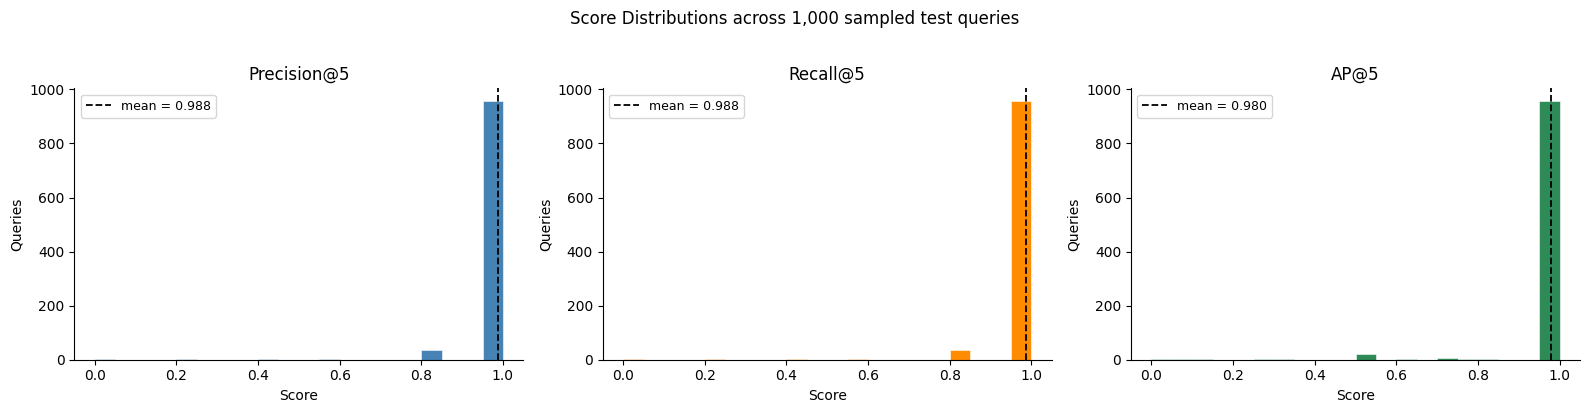


────────────────────────────────────────────────────────────────────
  BEST   — highest Precision@5
  Query : Les Bicyclettes de Belsize  (1968)  [British]
  Genres: ['musical']
  P@5=1.00   R@5=1.00   AP@5=1.00
  ────────────────────────────────────────────────────────────
    #1 ✓  Meet the People  (1944)  ['musical']
    #2 ✓  Calamity Jane  (1953)  ['musical']
    #3 ✓  The Pirate  (1948)  ['musical']
    #4 ✓  Holiday Inn  (1942)  ['musical']
    #5 ✓  The Glass Slipper  (1955)  ['musical']

────────────────────────────────────────────────────────────────────
  WORST  — lowest  Precision@5
  Query : Muppet Treasure Island  (1996)  [American]
  Genres: ['family']
  P@5=0.00   R@5=0.00   AP@5=0.00
  ────────────────────────────────────────────────────────────
    #1 ✗  Treasure Island  (1920)  ['adventure']
    #2 ✗  Treasure Island  (1934)  ['adventure']
    #3 ✗  Treasure Island  (1950)  ['adventure']
    #4 ✗  Treasure Island  (1918)  ['adventure']
    #5 ✗  Treasure Planet  (20

In [59]:
import matplotlib.pyplot as plt

# ── Summary table ─────────────────────────────────────────────────────────────
mean_p  = results_df['precision'].mean()
mean_r  = results_df['recall'].mean()
map_k   = results_df['ap'].mean()

print("╔══════════════════════════════════════════╗")
print(f"║  Evaluation Results  (n={len(results_df):,}, k={K})      ║")
print("╠══════════════════════════════════════════╣")
print(f"║  Mean Precision@{K}  :  {mean_p:.4f}              ║")
print(f"║  Mean Recall@{K}     :  {mean_r:.4f}              ║")
print(f"║  MAP@{K}             :  {map_k:.4f}              ║")
print("╚══════════════════════════════════════════╝")

# ── Distribution histograms ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
configs = [
    ('precision', f'Precision@{K}', 'steelblue'),
    ('recall',    f'Recall@{K}',    'darkorange'),
    ('ap',        f'AP@{K}',        'seagreen'),
]
for ax, (col, label, color) in zip(axes, configs):
    ax.hist(results_df[col], bins=20, color=color, edgecolor='white', linewidth=0.4)
    ax.axvline(results_df[col].mean(), color='black', linestyle='--', linewidth=1.3,
               label=f'mean = {results_df[col].mean():.3f}')
    ax.set_title(label)
    ax.set_xlabel('Score')
    ax.set_ylabel('Queries')
    ax.legend(fontsize=9)

plt.suptitle('Score Distributions across 1,000 sampled test queries', y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

# ── Best / Worst / Median examples ───────────────────────────────────────────
best_row   = results_df.loc[results_df['precision'].idxmax()]
worst_row  = results_df.loc[results_df['precision'].idxmin()]
med_target = results_df['precision'].median()
median_row = results_df.iloc[
    (results_df['precision'] - med_target).abs().argsort().iloc[0]
]

def print_example(label: str, row: pd.Series) -> None:
    qidx = int(row['query_idx'])
    qmov = df_filtered.iloc[qidx]
    print(f"\n{'─' * 68}")
    print(f"  {label}")
    print(f"  Query : {qmov['Title']}  ({int(qmov['Release_Year'])})  "
          f"[{qmov.get('Origin_Ethnicity', '')}]")
    print(f"  Genres: {qmov['genre_list']}")
    print(f"  P@{K}={row['precision']:.2f}   R@{K}={row['recall']:.2f}   AP@{K}={row['ap']:.2f}")
    print(f"  {'─' * 60}")
    for rank, cidx in enumerate(row['recs'], start=1):
        cmov    = df_filtered.iloc[cidx]
        marker  = '✓' if is_relevant(qidx, cidx, df_filtered) else '✗'
        print(f"    #{rank} {marker}  {cmov['Title']}  ({int(cmov['Release_Year'])})  "
              f"{cmov['genre_list']}")

for label, row in [
    (f"BEST   — highest Precision@{K}", best_row),
    (f"WORST  — lowest  Precision@{K}", worst_row),
    (f"MEDIAN — median  Precision@{K}", median_row),
]:
    print_example(label, row)

print(f"\n{'─' * 68}")

### 4.6 Diagnostic Statistics

─── 1. Mean Precision@5 by Genre Count ───────────────────────
  genre_count      mean P@5   n queries
  ──────────────────────────────────────
  1                  0.9896         847
  2                  0.9806         124
  3+                 0.9724          29

─── 2. Mean Precision@5 by Rarest-Genre Frequency ────────────
  (q25 cutoff = 364 movies,  q75 cutoff = 4230 movies)
  rarity bin               mean P@5   n queries
  ──────────────────────────────────────────────
  rare  (bottom 25%)         0.9749         255
  middle 50%                 0.9886         367
  common (top 25%)           0.9963         378

─── 3. Random Recommender Baseline ────────────────────────────
  Random Mean Precision@5  : 0.1454
  System Mean Precision@5  : 0.9880
  Absolute improvement       : +0.8426
  Relative lift              : +579.5%


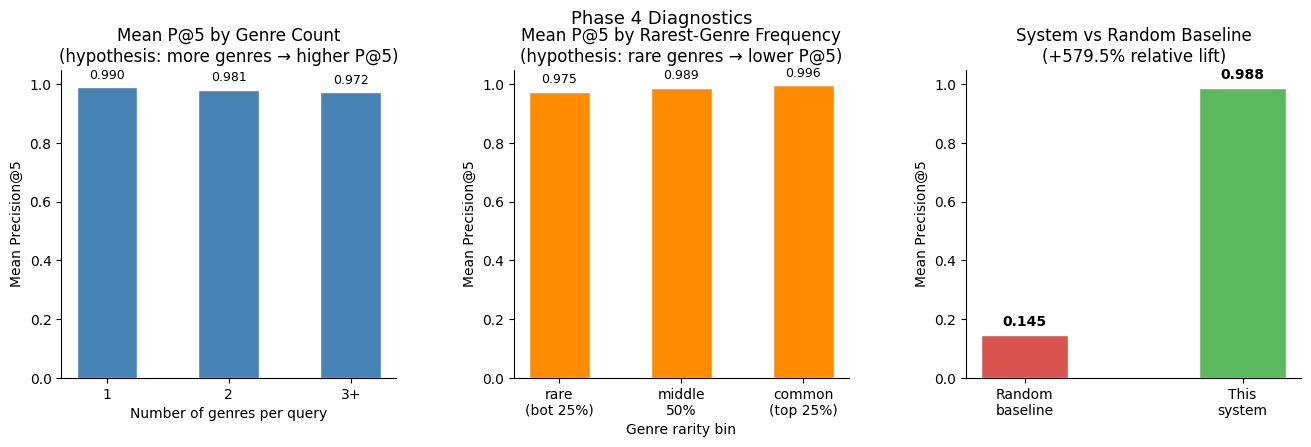

In [60]:
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# Attach per-query metadata (genre_count, genre_list) from df_filtered
diag = results_df.copy()
diag['genre_count'] = diag['query_idx'].map(df_filtered['genre_count'])
diag['genre_list']  = diag['query_idx'].map(lambda i: df_filtered.loc[i, 'genre_list'])

# ─────────────────────────────────────────────────────────────────────────────
# 1. Mean Precision@5 by genre_count
# ─────────────────────────────────────────────────────────────────────────────
diag['gc_bin'] = diag['genre_count'].apply(lambda x: '3+' if x >= 3 else str(x))

gc_table = (
    diag.groupby('gc_bin', sort=False)['precision']
    .agg(mean_p5='mean', n='count')
    .reindex(['1', '2', '3+'])
    .round(4)
)

print("─── 1. Mean Precision@5 by Genre Count ───────────────────────")
print(f"  {'genre_count':<14} {'mean P@5':>10}  {'n queries':>10}")
print(f"  {'─'*38}")
for label, row in gc_table.iterrows():
    print(f"  {label:<14} {row['mean_p5']:>10.4f}  {int(row['n']):>10,}")

# ─────────────────────────────────────────────────────────────────────────────
# 2. Mean Precision@5 by rarest-genre document frequency
# ─────────────────────────────────────────────────────────────────────────────
# Use training-set doc freq (that's what the model sees)
train_genre_freq = Counter(
    g for oi in train_idx_array
    for g in df_filtered.loc[oi, 'genre_list']
)

diag['rarest_freq'] = diag['genre_list'].apply(
    lambda genres: min((train_genre_freq.get(g, 0) for g in genres), default=0)
)

q25 = diag['rarest_freq'].quantile(0.25)
q75 = diag['rarest_freq'].quantile(0.75)

def _rarity_bin(freq):
    if freq <= q25:   return 'rare  (bottom 25%)'
    if freq >= q75:   return 'common (top 25%)'
    return              'middle 50%'

diag['rarity_bin'] = diag['rarest_freq'].apply(_rarity_bin)

BIN_ORDER = ['rare  (bottom 25%)', 'middle 50%', 'common (top 25%)']
rarity_table = (
    diag.groupby('rarity_bin', sort=False)['precision']
    .agg(mean_p5='mean', n='count')
    .reindex(BIN_ORDER)
    .round(4)
)

print(f"\n─── 2. Mean Precision@5 by Rarest-Genre Frequency ────────────")
print(f"  (q25 cutoff = {q25:.0f} movies,  q75 cutoff = {q75:.0f} movies)")
print(f"  {'rarity bin':<22} {'mean P@5':>10}  {'n queries':>10}")
print(f"  {'─'*46}")
for label, row in rarity_table.iterrows():
    print(f"  {label:<22} {row['mean_p5']:>10.4f}  {int(row['n']):>10,}")

# ─────────────────────────────────────────────────────────────────────────────
# 3. Random recommender baseline
# ─────────────────────────────────────────────────────────────────────────────
rng_baseline     = np.random.default_rng(123)
random_p5_scores = []

for qidx in diag['query_idx']:
    random_recs = rng_baseline.choice(train_idx_array, size=K, replace=False).tolist()
    random_p5_scores.append(precision_at_k(int(qidx), random_recs, df_filtered, k=K))

mean_random_p5 = float(np.mean(random_p5_scores))
lift = (mean_p - mean_random_p5) / mean_random_p5 * 100

print(f"\n─── 3. Random Recommender Baseline ────────────────────────────")
print(f"  Random Mean Precision@{K}  : {mean_random_p5:.4f}")
print(f"  System Mean Precision@{K}  : {mean_p:.4f}")
print(f"  Absolute improvement       : +{mean_p - mean_random_p5:.4f}")
print(f"  Relative lift              : +{lift:.1f}%")

# ─────────────────────────────────────────────────────────────────────────────
# Summary chart: 3 sub-plots side by side
# ─────────────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 4))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

# Plot 1 — by genre count
ax1   = fig.add_subplot(gs[0])
vals1 = gc_table['mean_p5'].values
lbls1 = gc_table.index.tolist()
bars1 = ax1.bar(lbls1, vals1, color='steelblue', edgecolor='white', width=0.5)
ax1.set_ylim(0, 1.05)
ax1.set_title('Mean P@5 by Genre Count\n(hypothesis: more genres → higher P@5)')
ax1.set_xlabel('Number of genres per query')
ax1.set_ylabel('Mean Precision@5')
for bar, v in zip(bars1, vals1):
    ax1.text(bar.get_x() + bar.get_width() / 2, v + 0.02, f'{v:.3f}',
             ha='center', va='bottom', fontsize=9)

# Plot 2 — by rarity
ax2   = fig.add_subplot(gs[1])
vals2 = rarity_table['mean_p5'].values
lbls2 = ['rare\n(bot 25%)', 'middle\n50%', 'common\n(top 25%)']
bars2 = ax2.bar(lbls2, vals2, color='darkorange', edgecolor='white', width=0.5)
ax2.set_ylim(0, 1.05)
ax2.set_title('Mean P@5 by Rarest-Genre Frequency\n(hypothesis: rare genres → lower P@5)')
ax2.set_xlabel('Genre rarity bin')
ax2.set_ylabel('Mean Precision@5')
for bar, v in zip(bars2, vals2):
    ax2.text(bar.get_x() + bar.get_width() / 2, v + 0.02, f'{v:.3f}',
             ha='center', va='bottom', fontsize=9)

# Plot 3 — system vs random
ax3    = fig.add_subplot(gs[2])
labels = [f'Random\nbaseline', f'This\nsystem']
vals3  = [mean_random_p5, mean_p]
colors = ['#d9534f', '#5cb85c']
bars3  = ax3.bar(labels, vals3, color=colors, edgecolor='white', width=0.4)
ax3.set_ylim(0, 1.05)
ax3.set_title(f'System vs Random Baseline\n(+{lift:.1f}% relative lift)')
ax3.set_ylabel('Mean Precision@5')
for bar, v in zip(bars3, vals3):
    ax3.text(bar.get_x() + bar.get_width() / 2, v + 0.02, f'{v:.3f}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('Phase 4 Diagnostics', fontsize=13, y=1.03)
plt.show()